In [11]:
from typing_extensions import TypedDict 

class State(TypedDict):
    my_state: str 


In [12]:
def node_1(state: State) -> State:
    print("node_1")
    print(state)
    new_state = state["my_state"] + "I want to travel to "
    return {"my_state": new_state}


def node_2(state: State) -> State:
    print("node_2")
    print(state)
    new_state = state["my_state"] + "Japan"
    return {"my_state": new_state}


def node_3(state: State) -> State:
    print("node_3")
    print(state)
    new_state = state["my_state"] + "Italy"
    return {"my_state": new_state}


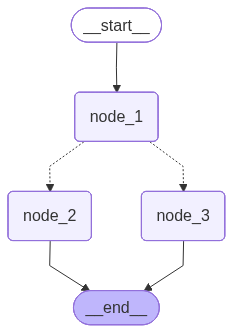

In [13]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
import random
from typing import Literal 


def decision_node(state:State) -> Literal["node_2","node_3"]:
    print("decision_node")
    print(state)
    return random.choice(["node_2","node_3"])

# initialize state
builder = StateGraph(State)

# add nodes
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# add edges
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1",decision_node)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# initialize graph
graph = builder.compile()

# shows the diagram
display(Image(graph.get_graph().draw_mermaid_png()))


In [14]:
graph.invoke({"my_state": "I am Alejandro "})

node_1
{'my_state': 'I am Alejandro '}
decision_node
{'my_state': 'I am Alejandro I want to travel to '}
node_2
{'my_state': 'I am Alejandro I want to travel to '}


{'my_state': 'I am Alejandro I want to travel to Japan'}

In [15]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq


load_dotenv()
llm = ChatGroq(model = "openai/gpt-oss-120b", api_key=os.environ.get("GROQ_API_KEY"))
response = llm.invoke("what is 523*780236")
response.pretty_print()

================================== Ai Message ==================================

523 × 780 236 = 408 063 428.


In [16]:
def multiply_numbers(a: int, b: int) -> int:
    """
    Multiply two numbers

    Args:
        a: int
        b: int
    """
    return a * b


tools = [multiply_numbers]
llm_with_tools = llm.bind_tools(tools)  
from pprint import pprint  
pprint(llm_with_tools.__dict__)

{'bound': ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020A49624DF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020A49625900>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')),
 'config': {},
 'config_factories': [],
 'custom_input_type': None,
 'custom_output_type': None,
 'kwargs': {'tools': [{'function': {'description': 'Multiply two numbers',
                                    'name': 'multiply_numbers',
                                    'parameters': {'properties': {'a': {'description': 'int',
                                                                        'type': 'integer'},
                                     

In [17]:
response = llm_with_tools.invoke("what is 523*780236")
response.__dict__

{'content': '',
 'additional_kwargs': {'reasoning_content': "We need to compute 523 * 780236. Use multiplication. Let's compute: 780,236 * 523.\n\nCompute 780,236 * 500 = 390,118,000\n780,236 * 20 = 15,604,720\n780,236 * 3 = 2,340,708\n\nSum: 390,118,000 + 15,604,720 = 405,722,720\nAdd 2,340,708 = 408,063,428.\n\nCheck: Let's do direct: 780,236 * 523 = 780,236 * (500+20+3) as above.\n\nThus answer 408,063,428.\n\nWe can also verify using function multiply_numbers.",
  'tool_calls': [{'id': 'fc_1ffb10e8-b699-4205-8946-6fde841202da',
    'function': {'arguments': '{"a":523,"b":780236}',
     'name': 'multiply_numbers'},
    'type': 'function'}]},
 'response_metadata': {'token_usage': {'completion_tokens': 190,
   'prompt_tokens': 132,
   'total_tokens': 322,
   'completion_time': 0.395216663,
   'completion_tokens_details': {'reasoning_tokens': 155},
   'prompt_time': 0.004999878,
   'prompt_tokens_details': None,
   'queue_time': 0.020581615,
   'total_time': 0.400216541},
  'model_name

In [18]:
from langgraph.graph import StateGraph, START, END, MessagesState

def llm_node(state: MessagesState) -> MessagesState:
    print()
    print("#" * 80)
    print("ENTERING LLM NODE")
    print(state)

    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


llm_node({"messages": ["what is 523*780236?"]})



################################################################################
ENTERING LLM NODE
{'messages': ['what is 523*780236?']}


{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to compute multiplication. Use function multiply_numbers.', 'tool_calls': [{'id': 'fc_a6e08ac4-59dc-4e82-9d06-0b32f90fd1fb', 'function': {'arguments': '{"a":523,"b":780236}', 'name': 'multiply_numbers'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 133, 'total_tokens': 180, 'completion_time': 0.097681626, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.005119036, 'prompt_tokens_details': None, 'queue_time': 0.030621301, 'total_time': 0.102800662}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_09abe4d7e3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--f4edfa6a-7953-4f60-b643-5f018847305f-0', tool_calls=[{'name': 'multiply_numbers', 'args': {'a': 523, 'b': 780236}, 'id': 'fc_a6e08ac4-59dc-4e82-9d06-0b32f90fd1fb', 'type': 'tool_call'}], usag

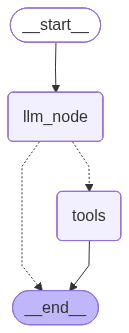

In [31]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

# define our tools
def multiply(a: int, b: int) -> int:
    """
    Multiply two numbers

    Args:
    a: The first number
    b: The second number
    """
    p = a * b 
    k = print("its sucess")

    return p,k

tools = [multiply]
llm = ChatGroq(model="openai/gpt-oss-120b")
llm_with_tools = llm.bind_tools(tools)
def llm_node(state: MessagesState) -> MessagesState:
    print()
    print("#" * 80)
    print("ENTERING LLM NODE")
    print(state)

    response = llm_with_tools.invoke(state["messages"])

    print("#" * 80)
    print("EXITING LLM NODE")
    return {"messages": [response]}


builder = StateGraph(MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", tools_condition)
builder.add_edge("tools",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
response = graph.invoke({"messages": [("user", "what is 523*788236?")]})


################################################################################
ENTERING LLM NODE
{'messages': [HumanMessage(content='what is 523*788236?', additional_kwargs={}, response_metadata={}, id='7e5f1c74-fa32-4816-a7b8-0ab7d6e6dff0')]}
################################################################################
EXITING LLM NODE
its sucess


In [33]:
response = graph.invoke({"messages": [("user", "what is 523*788236?")]})
for m in response["messages"]:
    m.pretty_print()


################################################################################
ENTERING LLM NODE
{'messages': [HumanMessage(content='what is 523*788236?', additional_kwargs={}, response_metadata={}, id='ef11113b-04f7-4020-9f89-a1536a57f277')]}
################################################################################
EXITING LLM NODE
its sucess
================================ Human Message =================================

what is 523*788236?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_446bf13f-0c5c-4233-a85b-1657874fdc1d)
 Call ID: fc_446bf13f-0c5c-4233-a85b-1657874fdc1d
  Args:
    a: 523
    b: 788236
================================= Tool Message =================================
Name: multiply

[412247428, null]


In [30]:
response = graph.invoke({"messages": [("user", "tell me about yourself")]})
for m in response["messages"]:
    m.pretty_print()


################################################################################
ENTERING LLM NODE
{'messages': [HumanMessage(content='tell me about yourself', additional_kwargs={}, response_metadata={}, id='210ad467-5e78-4eb6-8e01-9b7a609a6a58')]}
################################################################################
EXITING LLM NODE
================================ Human Message =================================

tell me about yourself
================================== Ai Message ==================================

I’m ChatGPT, a large‑language‑model AI created by OpenAI. I’ve been trained on a broad mix of internet text, books, code, and other sources, which lets me help with a wide range of tasks—answering questions, brainstorming ideas, explaining concepts, drafting emails or stories, troubleshooting code, tutoring in many subjects, and more.

A few quick facts about me:

- **Model family:** GPT‑4 architecture.  
- **Knowledge cutoff:** September 2021 for the core trai

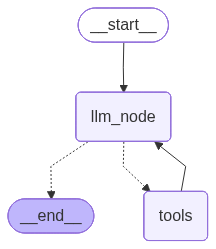

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_openai import ChatOpenAI


def get_temperature(city: str) -> float:
    """
    Get the temperature of a city

    Args:
        city: The city to get the temperature of
    """
    if city.lower() == "new york":
        return 21.5
    if city.lower() == "tokyo":
        return 26.3
    if city.lower() == "san francisco":
        return 18.2
    return 0.0
def convert_to_fahrenheit(celsius: float) -> float:
    """
    Convert a temperature in Celsius to Fahrenheit

    Args:
        celsius: The temperature in Celsius
    """
    return celsius * 9/5 + 32


tools = [get_temperature, convert_to_fahrenheit]

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def llm_node(state: MessagesState) -> MessagesState:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(MessagesState)

builder.add_node("llm_node", llm_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", tools_condition)
builder.add_edge("tools", "llm_node")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [ ]:
response = graph.invoke({
    "messages": [
        ("user", "what is the temperature in New York in Fahrenheit?")
    ]
})


In [41]:
for i in response["messages"]:
    i.pretty_print()

================================ Human Message =================================

what is the temperature in New York in Fahrenheit?
================================== Ai Message ==================================
Tool Calls:
  get_temperature (call_HPkj3uG3C9NutMXhj7hK9JGk)
 Call ID: call_HPkj3uG3C9NutMXhj7hK9JGk
  Args:
    city: New York
================================= Tool Message =================================
Name: get_temperature

21.5
================================== Ai Message ==================================
Tool Calls:
  convert_to_fahrenheit (call_Ap034TuCw0K2cHhPgGixsLSr)
 Call ID: call_Ap034TuCw0K2cHhPgGixsLSr
  Args:
    celsius: 21.5
================================= Tool Message =================================
Name: convert_to_fahrenheit

70.7
================================== Ai Message ==================================

The temperature in New York is 70.7°F.
